In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [153]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [154]:
cardiovascular = pd.read_csv("/content/drive/MyDrive/Projects/gdp-health-corruption/datasets/cardiovascular.csv")
gdp = pd.read_csv("/content/drive/MyDrive/Projects/gdp-health-corruption/datasets/gdp_per_capita.csv")
corruption = pd.read_csv("/content/drive/MyDrive/Projects/gdp-health-corruption/datasets/V-Dem/V-Dem-CY-Full+Others-v15.csv")
gdp_pct = pd.read_csv("/content/drive/MyDrive/Projects/gdp-health-corruption/datasets/gdp_pct.csv")

/tmp/ipython-input-3733453229.py:3: DtypeWarning: Columns (364,365,366,399,804,836,837,924,1240,1257,1486,3094,3168,3169,3341,3342,3344,3345,3347,3350,3352) have mixed types. Specify dtype option on import or set low_memory=False.
  corruption = pd.read_csv("/content/drive/MyDrive/Projects/gdp-health-corruption/datasets/V-Dem/V-Dem-CY-Full+Others-v15.csv")


In [261]:
corruption.columns

Index(['country_name', 'country_text_id', 'country_id', 'year',
       'historical_date', 'project', 'historical', 'histname', 'codingstart',
       'codingend',
       ...
       'e_mipopula', 'e_miurbani', 'e_pefeliex', 'e_wb_pop', 'e_pechmor',
       'e_miinteco', 'e_civil_war', 'e_miinterc', 'e_pt_coup',
       'e_pt_coup_attempts'],
      dtype='object', length=4607)

In [262]:
corruption.head()

,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,e_mipopula,e_miurbani,e_pefeliex,e_wb_pop,e_pechmor,e_miinteco,e_civil_war,e_miinterc,e_pt_coup,e_pt_coup_attempts
0,Mexico,MEX,3,1789,1789-12-31,1,1,Viceroyalty of New Spain,1789,2024,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
1,Mexico,MEX,3,1790,1790-12-31,1,1,Viceroyalty of New Spain,1789,2024,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
2,Mexico,MEX,3,1791,1791-12-31,1,1,Viceroyalty of New Spain,1789,2024,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
3,Mexico,MEX,3,1792,1792-12-31,1,1,Viceroyalty of New Spain,1789,2024,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
4,Mexico,MEX,3,1793,1793-12-31,1,1,Viceroyalty of New Spain,1789,2024,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN


In [263]:
cardiovascular.head()

,Entity,Code,Year,Age-standardized death rate from cardiovascular diseases among both sexes
0,Afghanistan,AFG,2000,696.05510
1,Afghanistan,AFG,2001,702.28590
2,Afghanistan,AFG,2002,692.65076
3,Afghanistan,AFG,2003,681.37740
4,Afghanistan,AFG,2004,675.17285


In [264]:
cardiovascular

,Entity,Code,Year,Age-standardized death rate from cardiovascular diseases among both sexes
0,Afghanistan,AFG,2000,696.05510
1,Afghanistan,AFG,2001,702.28590
2,Afghanistan,AFG,2002,692.65076
3,Afghanistan,AFG,2003,681.37740
4,Afghanistan,AFG,2004,675.17285
...,...,...,...,...
4417,Zimbabwe,ZWE,2017,361.24330
4418,Zimbabwe,ZWE,2018,364.30536
4419,Zimbabwe,ZWE,2019,352.93920
4420,Zimbabwe,ZWE,2020,379.96840


In [265]:
corruption.drop_duplicates(subset = "country_name")['country_name']

,country_name
0,Mexico
236,Suriname
361,Sweden
597,Switzerland
824,Ghana
...,...
27569,Brunswick
27643,Oldenburg
27720,Saxe-Weimar-Eisenach
27779,Nassau


In [266]:
paises_codes = ["DOM", "ARG", "CHL", "USA", "ESP", "KOR", "MEX"]

columnas_1 = [
    "country_name", "country_text_id", "year", "v2x_corr", "v2x_pubcorr",
    "v2x_execorr", "v2jucorrdc", "e_gdppc", "e_pechmor", "e_pematmor", "e_pelifeex"
]

In [267]:
corruption_filter = corruption[corruption["country_text_id"].isin(paises_codes)][columnas_1]

In [268]:
corruption_filter[corruption_filter['year'] >= 2000].head()

,country_name,country_text_id,year,v2x_corr,v2x_pubcorr,v2x_execorr,v2jucorrdc,e_gdppc,e_pechmor,e_pematmor,e_pelifeex
211,Mexico,MEX,2000,0.550,0.377,0.345,-0.539,29.475,26.36,67.0,74.21
212,Mexico,MEX,2001,0.548,0.355,0.363,-0.539,29.721,24.96,NaN,74.57
213,Mexico,MEX,2002,0.573,0.355,0.363,-0.539,29.761,23.65,NaN,74.62
214,Mexico,MEX,2003,0.608,0.497,0.363,-0.539,29.941,22.48,NaN,74.68
215,Mexico,MEX,2004,0.608,0.497,0.363,-0.539,30.521,21.44,NaN,75.05


In [269]:
corruption_filter.tail()

,country_name,country_text_id,year,v2x_corr,v2x_pubcorr,v2x_execorr,v2jucorrdc,e_gdppc,e_pechmor,e_pematmor,e_pelifeex
17235,Dominican Republic,DOM,2020,0.616,0.581,0.493,0.052,NaN,27.67,NaN,72.50
17236,Dominican Republic,DOM,2021,0.609,0.712,0.434,0.311,NaN,27.01,NaN,72.23
17237,Dominican Republic,DOM,2022,0.610,0.712,0.443,0.311,NaN,26.33,NaN,73.78
17238,Dominican Republic,DOM,2023,0.614,0.706,0.443,0.311,NaN,25.64,NaN,73.97
17239,Dominican Republic,DOM,2024,0.709,0.706,0.443,-0.732,NaN,24.98,NaN,74.15


In [270]:
corruption_filter['country_text_id'].drop_duplicates()

,country_text_id
0,MEX
2940,USA
5556,ARG
6469,KOR
10733,CHL
14609,ESP
17025,DOM


In [271]:
gdp.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27458.220150,27441.550210,28440.041690,30082.158420,30645.890600,22759.807180,26749.329610,30975.998910,35718.753120,39498.594130
1,Africa Eastern and Southern,AFE,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,240.911794,243.773593,...,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
3,Africa Western and Central,AFW,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,162.107340,144.940804,...,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448


In [272]:
gdp_filter = gdp[gdp['Country Code'].isin(paises_codes)]
gdp_filter.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
9,Argentina,ARG,778.251707,971.338043,870.217491,852.972425,1176.200862,1281.833380,1275.078434,1063.932838,...,13679.626500,12699.96231,14532.500930,11752.799890,9955.974787,8535.599380,10738.017920,13962.18941,14261.84657,13969.78366
39,Chile,CHL,516.487539,594.436306,678.584337,657.719197,685.970203,686.123542,790.361774,764.265129,...,13433.920300,13649.85205,14879.908620,15659.480870,14495.716720,13114.815470,16206.832550,15405.61658,17067.03648,16709.88940
59,Dominican Republic,DOM,205.731510,193.908989,236.814700,262.186358,277.297158,233.160574,250.876691,256.206597,...,6800.953094,7160.44201,7412.715716,7882.982216,8183.016236,7135.222733,8527.075486,10104.24493,10630.43174,10875.66184
70,Spain,ESP,407.963028,463.190441,535.391059,627.278451,694.952087,797.377066,915.629234,996.571863,...,25982.441620,26755.60611,28381.342560,30602.421290,29786.524570,27233.942650,30799.477590,30319.49872,33493.22254,35326.76831
126,"Korea, Rep.",KOR,158.844151,94.204594,106.623916,147.007905,124.241367,109.429277,134.431384,162.459908,...,30171.790650,30832.06281,33296.984540,35363.950820,33826.944330,33645.771950,37518.463530,34822.40484,35674.09600,36238.63991


In [273]:
gdp_filter['Country Name'].drop_duplicates()

,Country Name
9,Argentina
39,Chile
59,Dominican Republic
70,Spain
126,"Korea, Rep."
154,Mexico
251,United States


In [274]:
gdp_filter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 9 to 251
Data columns (total 67 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  7 non-null      object 
 1   Country Code  7 non-null      object 
 2   1960          7 non-null      float64
 3   1961          7 non-null      float64
 4   1962          7 non-null      float64
 5   1963          7 non-null      float64
 6   1964          7 non-null      float64
 7   1965          7 non-null      float64
 8   1966          7 non-null      float64
 9   1967          7 non-null      float64
 10  1968          7 non-null      float64
 11  1969          7 non-null      float64
 12  1970          7 non-null      float64
 13  1971          7 non-null      float64
 14  1972          7 non-null      float64
 15  1973          7 non-null      float64
 16  1974          7 non-null      float64
 17  1975          7 non-null      float64
 18  1976          7 non-null      float64

In [275]:
anios = [str(i) for i in range(1960, 2025)]

# 2. Definimos el orden que tú quieres
nuevo_orden = anios + ["Country Name", "Country Code"]

# 3. Reordenamos el DataFrame
gdp_filter = gdp_filter[nuevo_orden]

In [276]:
gdp_filter = gdp_filter.melt(id_vars=["Country Name", "Country Code"],
                   var_name="Year",
                   value_name="Valor_Indicador")

In [277]:
gdp_filter['Year'] = gdp_filter['Year'].astype('int')

In [278]:
gdp_filter.head()

,Country Name,Country Code,Year,Valor_Indicador
0,Argentina,ARG,1960,778.251707
1,Chile,CHL,1960,516.487539
2,Dominican Republic,DOM,1960,205.731510
3,Spain,ESP,1960,407.963028
4,"Korea, Rep.",KOR,1960,158.844151


In [279]:
gdp_pct_filter = gdp_pct[gdp_pct['Country Code'].isin(paises_codes)]

anios = [str(i) for i in range(1960, 2025)]

# 2. Definimos el orden que tú quieres
nuevo_orden = anios + ["Country Name", "Country Code"]

# 3. Reordenamos el DataFrame
gdp_pct_filter = gdp_pct_filter[nuevo_orden]

gdp_pct_filter = gdp_pct_filter.melt(id_vars=["Country Name", "Country Code"],
                   var_name="Year",
                   value_name="Valor_Indicador")

In [280]:
gdp_pct_filter

,Country Name,Country Code,Year,Valor_Indicador
0,Argentina,ARG,1960,NaN
1,Chile,CHL,1960,NaN
2,Dominican Republic,DOM,1960,NaN
3,Spain,ESP,1960,NaN
4,"Korea, Rep.",KOR,1960,NaN
...,...,...,...,...
450,Dominican Republic,DOM,2024,NaN
451,Spain,ESP,2024,NaN
452,"Korea, Rep.",KOR,2024,8.67657
453,Mexico,MEX,2024,NaN


In [281]:
nombres_domi = gdp[gdp['Country Code'].str.contains('EU', na=False)]['Country Code'].unique()
print(nombres_domi)

['DEU' 'EUU']


In [282]:
cardiovascular_filter = cardiovascular[cardiovascular['Code'].isin(paises_codes)]
cardiovascular_filter.head()

,Entity,Code,Year,Age-standardized death rate from cardiovascular diseases among both sexes
154,Argentina,ARG,2000,218.95592
155,Argentina,ARG,2001,219.34581
156,Argentina,ARG,2002,218.04173
157,Argentina,ARG,2003,214.37254
158,Argentina,ARG,2004,200.15195


In [283]:
cardiovascular_filter.drop_duplicates(subset='Code')

,Entity,Code,Year,Age-standardized death rate from cardiovascular diseases among both sexes
154,Argentina,ARG,2000,218.95592
792,Chile,CHL,2000,170.56232
1144,Dominican Republic,DOM,2000,191.49889
2486,Mexico,MEX,2000,151.47618
3696,South Korea,KOR,2000,187.28851
3740,Spain,ESP,2000,146.66719
4202,United States,USA,2000,203.80440


In [284]:
filtro_card = cardiovascular_filter[cardiovascular_filter['Code'] == 'DOM']['Year']
filtro_corr = corruption_filter[corruption_filter['country_text_id'] == 'DOM']['year']
filtro_gdp = gdp_filter[gdp_filter['Country Code'] == 'DOM']['Year']

In [285]:
print(f'La fecha mínimo de cardiovascular en Rep. Dom. es {filtro_card.min()} y el máximo es {filtro_card.max()}')
print(f'La fecha mínimo del índice de corrupción es Rep. Dom. es {filtro_corr.min()} y la máxima es {filtro_corr.max()}')
print(f'La fecha mínimo de PIB per capita en Rep. Dom. es {filtro_gdp.min()} y la máxima es {filtro_gdp.max()}')

La fecha mínimo de cardiovascular en Rep. Dom. es 2000 y el máximo es 2021
La fecha mínimo del índice de corrupción es Rep. Dom. es 1789 y la máxima es 2024
La fecha mínimo de PIB per capita en Rep. Dom. es 1960 y la máxima es 2024


In [286]:
gdp_filter = gdp_filter.rename(columns={
    'Country Name': 'Pais',
    'Country Code': 'Codigo',
    'Year': 'Anio',
    'Valor_Indicador': 'GDP'
})

gdp_pct_filter = gdp_pct_filter.rename(columns={
    'Country Name': 'Pais',
    'Country Code': 'Codigo',
    'Year': 'Anio',
    'Valor_Indicador': 'GDP_pct'
})

# cardiovascular_filter: [Entity, Code, Year, Age-standardized...]
cardiovascular_filter = cardiovascular_filter.rename(columns={
    'Entity': 'Pais',
    'Code': 'Codigo',
    'Year': 'Anio',
    'Age-standardized death rate from cardiovascular diseases among both sexes': 'Mortalidad_Cardio'
})

# corruption_filter: [country_name, country_text_id, year, ...]
# Seleccionamos solo las columnas importantes para no arrastrar las 4607 columnas
corruption_filter = corruption_filter[['country_name', 'country_text_id', 'year', 'v2x_corr','e_pechmor', 'e_pematmor','e_pelifeex']].copy()
corruption_filter = corruption_filter.rename(columns={
    'country_name': 'Pais',
    'country_text_id': 'Codigo',
    'year': 'Anio',
    'v2x_corr': 'Corruption_index',
    'e_pechmor': 'Mortalidad_infantil',
    'e_pematmor': 'Mortalidad_materna',
    'e_pelifeex': 'Esperanza_vida'
})

In [287]:
for df in [gdp_filter, cardiovascular_filter, corruption_filter, gdp_pct_filter]:
    df['Anio'] = df['Anio'].astype(int)

In [288]:
# 3. Realizar el Merge (unión)
df_merge = pd.merge(gdp_filter, cardiovascular_filter, on=['Codigo', 'Anio'], suffixes=('', '_drop'))

df_merge_1 = pd.merge(df_merge, gdp_pct_filter, on=['Codigo', 'Anio'], suffixes=('', '_drop'))

df_final = pd.merge(df_merge_1, corruption_filter, on=['Codigo', 'Anio'], suffixes=('', '_drop'))

In [289]:
# 4. Limpiar columnas duplicadas de nombres de países y filtrar por fechas
# Eliminamos columnas de nombre que se repiten y filtramos años 2000-2019
columnas_a_mantener = [c for c in df_final.columns if not c.endswith('_drop')]
df_final = df_final[columnas_a_mantener]

resultado = df_final[(df_final['Anio'] >= 2000) & (df_final['Anio'] <= 2019)]

In [290]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 139
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Pais                 140 non-null    object 
 1   Codigo               140 non-null    object 
 2   Anio                 140 non-null    int64  
 3   GDP                  140 non-null    float64
 4   Mortalidad_Cardio    140 non-null    float64
 5   GDP_pct              140 non-null    float64
 6   Corruption_index     140 non-null    float64
 7   Mortalidad_infantil  140 non-null    float64
 8   Mortalidad_materna   28 non-null     float64
 9   Esperanza_vida       140 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 12.0+ KB


In [315]:
resultado

,Pais,Codigo,Anio,GDP,Mortalidad_Cardio,GDP_pct,Corruption_index,Mortalidad_infantil,Mortalidad_materna,Esperanza_vida
0,Argentina,ARG,2000,7637.014892,218.955920,8.220011,0.460,19.62,63.0,74.22
1,Chile,CHL,2000,5052.992458,170.562320,7.000207,0.061,10.89,29.0,76.93
2,Dominican Republic,DOM,2000,2831.458836,191.498890,4.884275,0.783,40.92,120.0,73.66
3,Spain,ESP,2000,14743.267100,146.667190,6.802178,0.039,5.44,5.0,79.47
4,"Korea, Rep.",KOR,2000,12710.299580,187.288510,3.717948,0.238,7.48,19.0,76.34
...,...,...,...,...,...,...,...,...,...,...
135,Dominican Republic,DOM,2019,8183.016236,209.424380,4.368089,0.808,28.29,NaN,73.19
136,Spain,ESP,2019,29786.524570,77.773895,9.215395,0.037,2.93,NaN,83.09
137,"Korea, Rep.",KOR,2019,33826.944330,62.050346,7.693971,0.114,3.03,NaN,82.92
138,Mexico,MEX,2019,10369.555360,146.681200,5.301346,0.611,12.52,NaN,75.63


Efectos

In [291]:
import statsmodels.api as sm

In [292]:
# 1. Diccionario de Población Proyectada 2025 (Estimaciones)
poblacion_2025 = {
    "DOM": 11500000,
    "ARG": 46600000,
    "CHL": 20100000,
    "USA": 345000000,
    "ESP": 48200000,
    "KOR": 51800000,
    "MEX": 132300000
}

In [293]:
# 1. Definimos las variables independientes (X)
# Queremos ver el efecto de: Gasto en salud (% PIB) y Corrupción
X = resultado[['GDP_pct', 'Corruption_index']]
X = sm.add_constant(X)  # Añadimos una constante para el intercepto

def estimar_impacto(target_column):
    # Eliminamos filas con valores nulos en la columna objetivo (especialmente para materna)
    df_temp = resultado.dropna(subset=[target_column])

    # Ajustamos el modelo
    model = sm.OLS(df_temp[target_column], X.loc[df_temp.index]).fit()

    # Coeficientes
    coef_gdp = model.params['GDP_pct']
    coef_corr = model.params['Corruption_index']

    return model, coef_gdp, coef_corr

In [294]:
# 2. Ejecutamos para cada indicador
targets = ['Mortalidad_Cardio', 'Mortalidad_infantil', 'Mortalidad_materna', 'Esperanza_vida']
resultados_analisis = {}

for t in targets:
    model, gdp_eff, corr_eff = estimar_impacto(t)
    resultados_analisis[t] = {'gdp_effect': gdp_eff, 'corr_effect': corr_eff, 'rsquared': model.rsquared}

In [295]:
# --- CÁLCULO DE LA CONCLUSIÓN FINAL ---

# Supongamos que queremos calcular cuántas muertes "causa" la corrupción
# comparando el nivel actual contra un nivel de corrupción "bajo" (ej. 0.1)
corrupcion_actual = resultado['Corruption_index'].mean()
reduccion_ideal = corrupcion_actual - 0.1

print("--- IMPACTO ESTIMADO ---")
for t, vals in resultados_analisis.items():
    impacto_total = vals['corr_effect'] * reduccion_ideal

    if "Mortalidad" in t:
        print(f"Por cada punto que sube la corrupción, la {t} aumenta en: {vals['corr_effect']:.2f} personas (por cada 100k hab).")
        print(f"La corrupción actual 'aporta' {impacto_total:.2f} muertes anuales por cada 100k hab.\n")
    else:
        print(f"La corrupción reduce la esperanza de vida en: {abs(vals['corr_effect']):.2f} años por cada punto de índice.\n")

--- IMPACTO ESTIMADO ---
Por cada punto que sube la corrupción, la Mortalidad_Cardio aumenta en: 108.37 personas (por cada 100k hab).
La corrupción actual 'aporta' 24.45 muertes anuales por cada 100k hab.

Por cada punto que sube la corrupción, la Mortalidad_infantil aumenta en: 30.50 personas (por cada 100k hab).
La corrupción actual 'aporta' 6.88 muertes anuales por cada 100k hab.

Por cada punto que sube la corrupción, la Mortalidad_materna aumenta en: 119.95 personas (por cada 100k hab).
La corrupción actual 'aporta' 27.07 muertes anuales por cada 100k hab.

La corrupción reduce la esperanza de vida en: 9.68 años por cada punto de índice.



Por país

In [296]:
# 2. Configuración de Variables
targets = ['Mortalidad_Cardio', 'Mortalidad_infantil', 'Mortalidad_materna', 'Esperanza_vida']
independientes = ['GDP_pct', 'Corruption_index']
paises_codes = ["DOM", "ARG", "CHL", "USA", "ESP", "KOR", "MEX"]

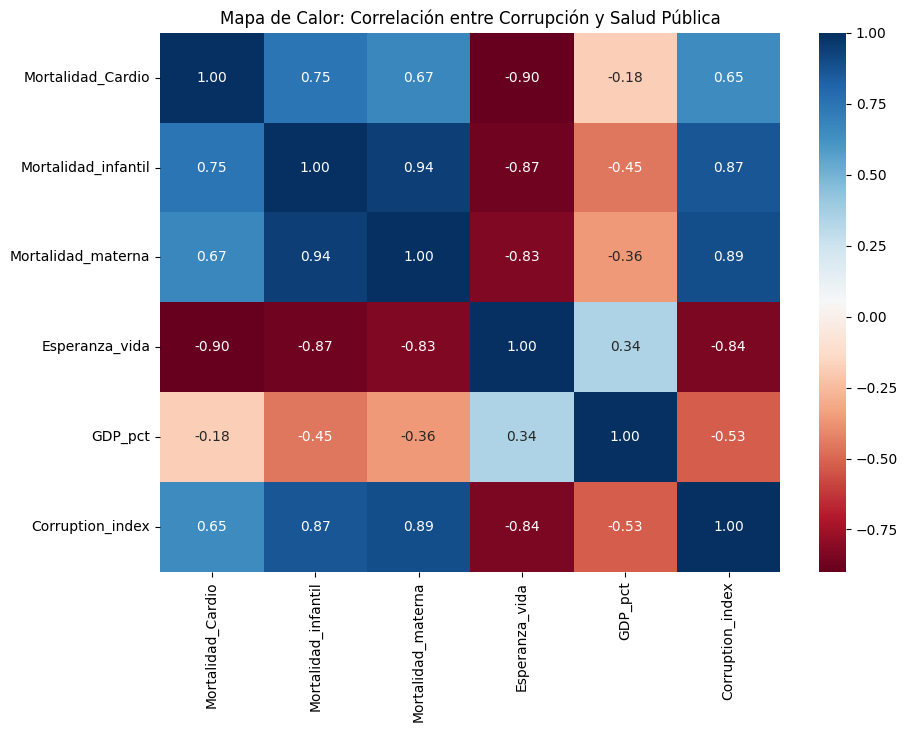

In [339]:
# 3. Gráfico de Correlación (Gama de Azules)
plt.figure(figsize=(10, 7))
sns.heatmap(resultado[targets + independientes].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Mapa de Calor: Correlación entre Corrupción y Salud Pública')
plt.show()

In [336]:
# 4. Cálculo de Modelos y Reporte por País
coefs = {}
for t in targets:
    # Eliminamos nulos para que la regresión no falle (especial para materna)
    df_sub = resultado.dropna(subset=[t] + independientes)
    if len(df_sub) > 2:
        modelo = sm.OLS(df_sub[t], sm.add_constant(df_sub[independientes])).fit()
        coefs[t] = modelo.params['Corruption_index']

print("\n" + "="*60)
print("REPORTE DE IMPACTO: ¿CUÁNTAS VIDAS SE PIERDEN POR CORRUPCIÓN?")
print("="*60)

for cod in paises_codes:
    if cod in resultado['Codigo'].values:
        data_pais = resultado[resultado['Codigo'] == cod].iloc[-1] # Último año disponible
        pop = poblacion_2025[cod]
        corr = data_pais['Corruption_index']

        # Cálculos de impacto (Ajuste de tasas)
        m_cardio = (coefs['Mortalidad_Cardio'] * corr) * (pop / 100000)
        e_vida = coefs['Esperanza_vida'] * corr

        print(f"\n📍 {data_pais['Pais']} (Índice de Corrupción: {corr:.2f})")
        print(f"  • Mortalidad Cardio: La corrupción mata indirectamente a {abs(int(m_cardio))} personas/año.")
        print(f"  • Esperanza de Vida: Se reduce en {abs(e_vida):.2f} años debido a la corrupción.")


REPORTE DE IMPACTO: ¿CUÁNTAS VIDAS SE PIERDEN POR CORRUPCIÓN?

📍 Dominican Republic (Índice de Corrupción: 0.81)
  • Mortalidad Cardio: La corrupción mata indirectamente a 10069 personas/año.
  • Esperanza de Vida: Se reduce en 7.82 años debido a la corrupción.

📍 Argentina (Índice de Corrupción: 0.41)
  • Mortalidad Cardio: La corrupción mata indirectamente a 20654 personas/año.
  • Esperanza de Vida: Se reduce en 3.96 años debido a la corrupción.

📍 Chile (Índice de Corrupción: 0.06)
  • Mortalidad Cardio: La corrupción mata indirectamente a 1219 personas/año.
  • Esperanza de Vida: Se reduce en 0.54 años debido a la corrupción.

📍 United States (Índice de Corrupción: 0.10)
  • Mortalidad Cardio: La corrupción mata indirectamente a 36264 personas/año.
  • Esperanza de Vida: Se reduce en 0.94 años debido a la corrupción.

📍 Spain (Índice de Corrupción: 0.04)
  • Mortalidad Cardio: La corrupción mata indirectamente a 1932 personas/año.
  • Esperanza de Vida: Se reduce en 0.36 años deb

In [305]:
resultado[resultado['Codigo'] == 'DOM'].iloc[-1]

,135
Pais,Dominican Republic
Codigo,DOM
Anio,2019
GDP,8183.016236
Mortalidad_Cardio,209.42438
GDP_pct,4.368089
Corruption_index,0.808
Mortalidad_infantil,28.29
Mortalidad_materna,NaN
Esperanza_vida,73.19


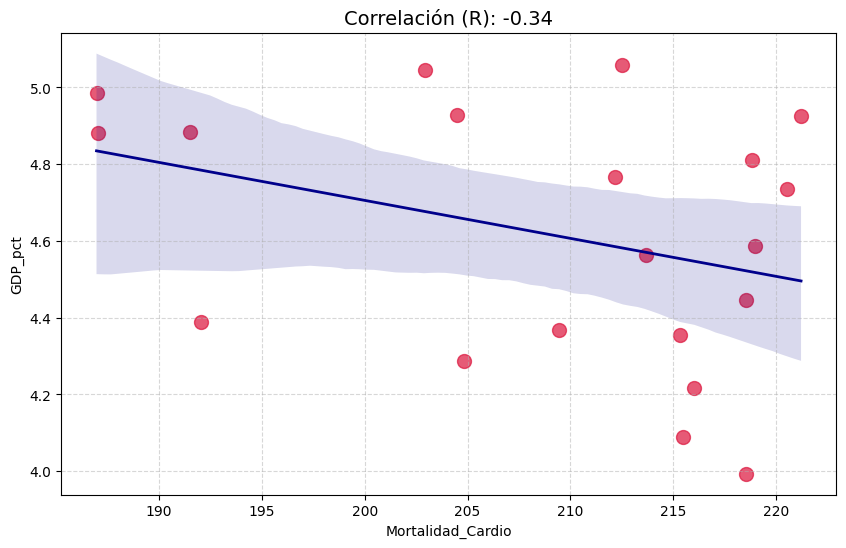

La correlación es de -0.3418.
Interpretación: Existe una relación


In [337]:
# 1. Filtramos solo los datos de República Dominicana
df_dom = resultado[resultado['Codigo'] == 'DOM'].copy()

# 2. Calculamos el coeficiente de correlación (R)
correlacion = df_dom['Mortalidad_Cardio'].corr(df_dom['GDP_pct'])

# 3. Creamos el Scatterplot con línea de regresión
plt.figure(figsize=(10, 6))

# Usamos regplot que añade automáticamente la línea de tendencia y el intervalo de confianza
sns.regplot(
    data=df_dom,
    x='Mortalidad_Cardio',
    y='GDP_pct',
    color='crimson',       # Color rojo para destacar
    marker='o',            # Forma de los puntos
    scatter_kws={'s': 100, 'alpha': 0.7}, # Puntos grandes y semitransparentes
    line_kws={'color': 'darkblue', 'linewidth': 2} # Línea de tendencia azul oscura
)

# 4. Detalles del gráfico
plt.title(f'Correlación (R): {correlacion:.2f}', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

print(f"La correlación es de {correlacion:.4f}.")
if correlacion < 0:
    print("Interpretación: Existe una relación")
else:
    print("Interpretación: Existe una relación")

AttributeError: 'Axes' object has no attribute 'get_legend_labels'

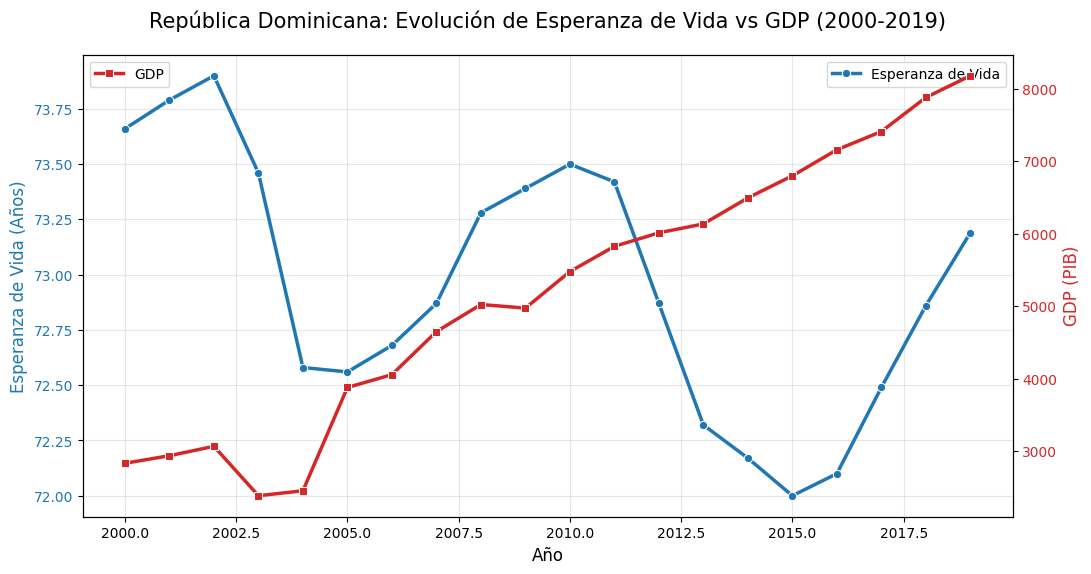

In [312]:
# 1. Filtramos y ordenamos por año para que la línea no se cruce
df_dom = resultado[resultado['Codigo'] == 'DOM'].sort_values('Anio')

# 2. Creamos la figura y el primer eje (Izquierdo - Esperanza de Vida)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_vida = '#1f77b4' # Azul
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Esperanza de Vida (Años)', color=color_vida, fontsize=12)
sns.lineplot(data=df_dom, x='Anio', y='Esperanza_vida', ax=ax1, color=color_vida, marker='o', linewidth=2.5, label='Esperanza de Vida')
ax1.tick_params(axis='y', labelcolor=color_vida)
ax1.grid(True, alpha=0.3)

# 3. Creamos el segundo eje (Derecho - GDP)
ax2 = ax1.twinx()
color_gdp = '#d62728' # Rojo/Carmesí
ax2.set_ylabel('GDP (PIB)', color=color_gdp, fontsize=12)
sns.lineplot(data=df_dom, x='Anio', y='GDP', ax=ax2, color=color_gdp, marker='s', linewidth=2.5, label='GDP')
ax2.tick_params(axis='y', labelcolor=color_gdp)

# 4. Título y leyenda
plt.title('República Dominicana: Evolución de Esperanza de Vida vs GDP (2000-2019)', fontsize=15, pad=20)

# Combinar leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_labels()
# ax1.legend(lines + lines2, labels + labels2, loc='upper left') # Opcional: unir leyendas

fig.tight_layout()
plt.show()

# Correlación numérica
corr = df_dom['GDP'].corr(df_dom['Esperanza_vida'])
print(f"Coeficiente de correlación de Pearson: {corr:.4f}")

In [333]:
resultado[['Pais',"Mortalidad_materna"]]

,Pais,Mortalidad_materna
0,Argentina,63.0
1,Chile,29.0
2,Dominican Republic,120.0
3,Spain,5.0
4,"Korea, Rep.",19.0
...,...,...
135,Dominican Republic,NaN
136,Spain,NaN
137,"Korea, Rep.",NaN
138,Mexico,NaN
